<a href="https://colab.research.google.com/github/debi201326/Shallow-and-Deep-Learning/blob/main/SDL_Practical_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analyzing Overfitting, Underfitting, and Good Fit in Predicting Student CGPA vs Package.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [ ]:
data = pd.read_csv("/content/placement.csv")
print(data.head())

   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


In [ ]:
X = data[['cgpa']].values
y = data[['package']].values

In [ ]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

In [ ]:
under_model = Sequential([
    Dense(1, input_dim=1, activation='linear')
])
under_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
under_model.fit(X_train, y_train, epochs=100, verbose=0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
X_line = np.linspace(0, 1, 100).reshape(-1, 1)
y_under_pred = under_model.predict(X_line)
y_under_pred = scaler_y.inverse_transform(y_under_pred)
X_line_real = scaler_X.inverse_transform(X_line)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


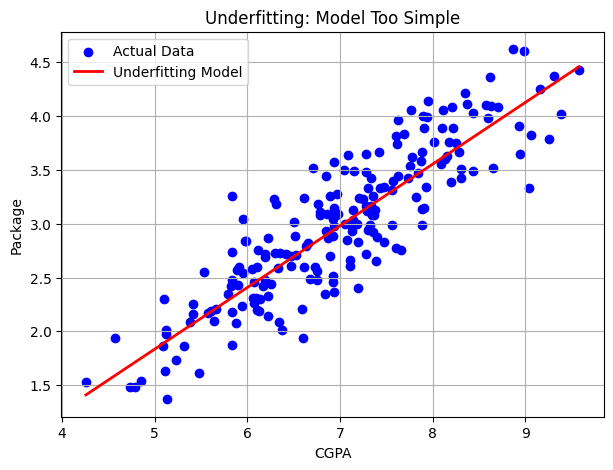

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_line_real, y_under_pred, color='red', linewidth=2, label='Underfitting Model')
plt.title("Underfitting: Model Too Simple")
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
over_model = Sequential([
    Dense(128, input_dim=1, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1, activation='linear')
])
over_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
over_model.fit(X_train, y_train, epochs=300, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
y_over_pred = over_model.predict(X_line)
y_over_pred = scaler_y.inverse_transform(y_over_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


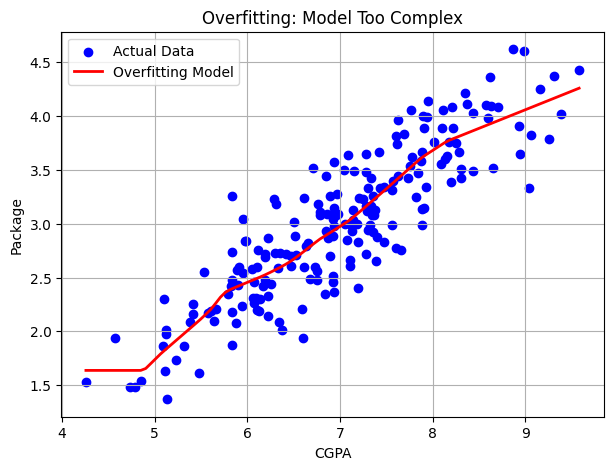

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_line_real, y_over_pred, color='red', linewidth=2, label='Overfitting Model')
plt.title("Overfitting: Model Too Complex")
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
good_model = Sequential([
    Dense(16, input_dim=1, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])
good_model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
good_model.fit(X_train, y_train, epochs=150, verbose=0)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
y_good_pred = good_model.predict(X_line)
y_good_pred = scaler_y.inverse_transform(y_good_pred)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


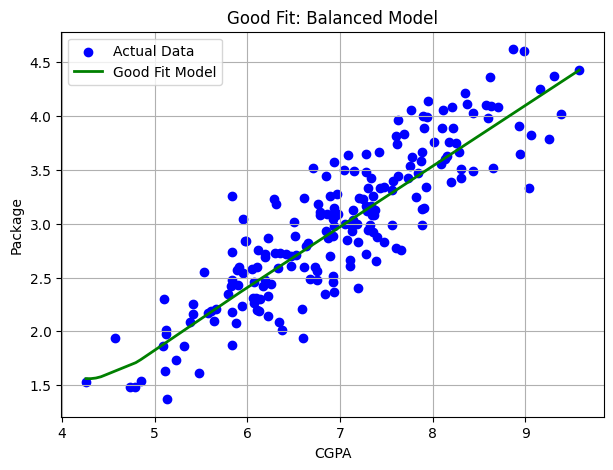

In [ ]:
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X_line_real, y_good_pred, color='green', linewidth=2, label='Good Fit Model')
plt.title("Good Fit: Balanced Model")
plt.xlabel("CGPA")
plt.ylabel("Package")
plt.legend()
plt.grid(True)
plt.show()